In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

### $$
S_{t+1} = S_t \exp\left(\left(\mu - \frac{1}{2}\sigma^2\right)\Delta t + \sigma\sqrt{\Delta t}\,Z\right)
$$

#### This is essentially just a very fancy geometric sequence ($z_{n+1}$ = $a$$z_{n}$), which has a general solution of $z_{n}$ = $a^{n}$$z_{0}$ (shoutout WTW 152). Only difference is the $a$ term changes due to the random shock (rv $Z$ ~ $N$(0, 1))
i.e
$$
\begin{aligned}
\text{Day 1: } & S_1 = S_0 \times \text{growth}_1 \\
\text{Day 2: } & S_2 = S_0 \times \text{growth}_1 \times \text{growth}_2 \\
\text{Day 3: } & S_3 = S_0 \times \text{growth}_1 \times \text{growth}_2 \times \text{growth}_3
\end{aligned}
$$

In [2]:
np.random.seed(42)                 # Insert a number if you want reproducibility, leave blank for complete randomness

mu = 0.08                        # Expected annual return (%)
sigma = 0.15                     # Annual volatility (%)
dt = 1/252                       # Length of 1 time step (usual 252 trading days in a year)
days = 252                       # Number of trading days simulated
paths = 10000                    # Number of paths to be simulated
S_0 = 100                        # Initial stock price
Z = np.random.randn(days, paths) # Random shock where Z ~ N(0, 1)

growth = np.exp((mu - sigma**2/2)*dt + sigma*np.sqrt(dt)*Z) # Obtaining the 'a' term
S_t = S_0 * np.cumprod(growth, axis = 0) # The growth factor compounds so thats what cumprod does
S_t = np.insert(S_t, 0, S_0, axis = 0) # Have to prepend the initial value since cumprod it is chnaged by the first multiplication

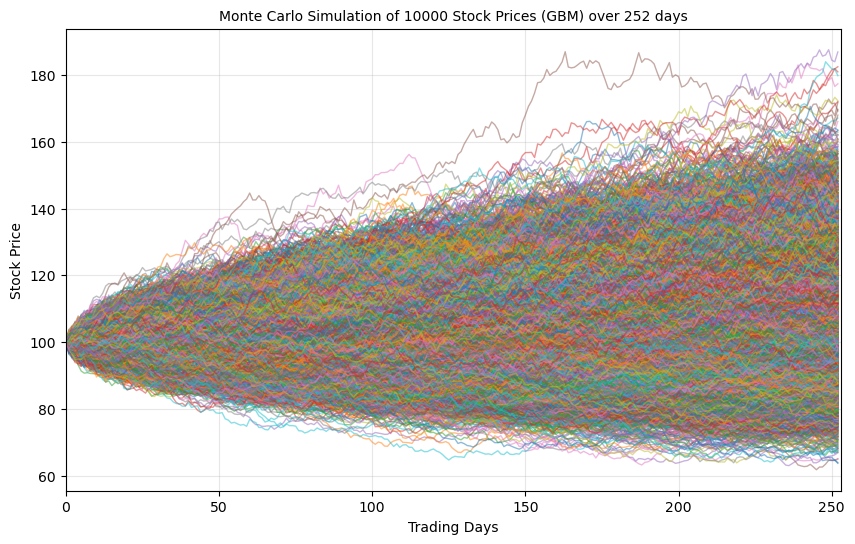

In [3]:
# Plotting all paths

plt.figure(figsize=(10, 6))
plt.plot(S_t, linewidth = 1, alpha = .5)
plt.title(f'Monte Carlo Simulation of {paths} Stock Prices (GBM) over {days} days', fontsize = 10)
plt.xlabel('Trading Days')
plt.ylabel('Stock Price')
plt.xlim(0, days+1)
plt.grid(True, alpha=0.3)
plt.show()

In [4]:
# Summary statistics

print(f"""=== SUMMARY STATISTICS ===
Final prices
Mean:                  ${np.mean(S_t[-1,:]):.2f}
Std:                   ${np.std(S_t[-1,:]):.2f}
Probability of profit: {(S_t[-1,:] > S_0).mean()*100:.1f}% 
""")

# Mean
# Standard deviation
# Checking if the final price is higher than inital and calulating the proportion that is such

=== SUMMARY STATISTICS ===
Final prices
Mean:                  $108.20
Std:                   $16.26
Probability of profit: 67.7% 



In [5]:
# Representation of daily price data

col_headers = list((f'Sim {i}') for i in range(1, paths+1))
row_headers = list((f'Day {j}') for j in range(0, days+1))

daily_price = pd.DataFrame(
    np.round(S_t, 2),
    columns = col_headers,
    index = row_headers
)
daily_price

,Sim 1,Sim 2,Sim 3,Sim 4,Sim 5,Sim 6,Sim 7,Sim 8,Sim 9,Sim 10,...,Sim 9991,Sim 9992,Sim 9993,Sim 9994,Sim 9995,Sim 9996,Sim 9997,Sim 9998,Sim 9999,Sim 10000
Day 0,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,...,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00
Day 1,100.50,99.90,100.64,101.48,99.81,99.81,101.53,100.76,99.58,100.54,...,101.39,100.21,100.66,98.62,101.16,101.26,98.16,99.36,100.50,100.64
Day 2,99.88,99.64,100.10,101.61,100.97,99.11,102.52,100.04,98.82,101.35,...,102.61,99.79,101.53,99.49,102.10,101.66,99.47,99.75,102.17,99.14
Day 3,100.24,99.93,99.25,102.20,99.58,98.52,100.63,101.55,98.63,103.47,...,102.42,101.56,102.40,98.37,100.92,101.14,100.86,99.30,100.38,98.95
Day 4,98.41,98.97,98.73,102.37,100.58,99.20,99.54,101.22,98.73,103.25,...,104.24,102.54,102.59,97.84,100.02,102.24,101.14,99.91,101.19,99.31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Day 248,137.76,120.20,109.10,109.72,117.42,130.50,100.22,125.87,136.09,138.42,...,64.75,126.11,95.60,113.46,109.45,148.61,93.18,102.33,81.28,93.16
Day 249,137.37,121.49,107.98,110.93,117.56,130.28,99.13,127.69,133.90,136.55,...,64.75,127.00,95.33,113.17,107.92,146.87,93.84,101.58,81.86,94.03
Day 250,138.09,121.94,107.64,109.28,117.79,130.01,98.29,129.90,134.27,137.30,...,64.63,126.72,95.41,113.79,108.79,145.18,95.61,100.83,81.07,94.83
Day 251,137.52,123.20,107.99,108.84,117.62,130.00,97.59,129.87,134.68,139.44,...,64.72,130.65,96.34,114.09,107.93,146.15,96.29,102.33,81.38,94.29


In [6]:
# Value at Risk (VaR) caluclations

profit_or_loss = daily_price.iloc[days] - S_0
returns = (daily_price.iloc[-1] / S_0 - 1) * 100

#Calculating mean, min and max return
summary = pd.DataFrame(returns).agg(
    ['mean',
     'min',
     'max'
    ]
)

# Note that the negatives are meant to represent losses
var90 = np.quantile(returns, 0.1)
var95 = np.quantile(returns, 0.05)
var99 = np.quantile(returns, 0.01)

summary.loc['90% VaR'] = var90 # e.g., there is a 10% probability that losses will not exceed this value
summary.loc['95% VaR'] = var95
summary.loc['99% VaR'] = var99

worst_cases_5percent = returns[returns < var95]
CVaR = worst_cases_5percent.mean() # If I am in the worst 5% of losses, what is the average return i could expect?
summary.loc['CVaR'] = CVaR

summary.columns = ['VaR summary'] # Changing the column heading for visual purposes
summary.style.format("{:.2f}%")

,VaR summary
mean,8.20%
min,-36.25%
max,86.86%
90% VaR,-11.82%
95% VaR,-16.30%
99% VaR,-24.70%
CVaR,-21.30%


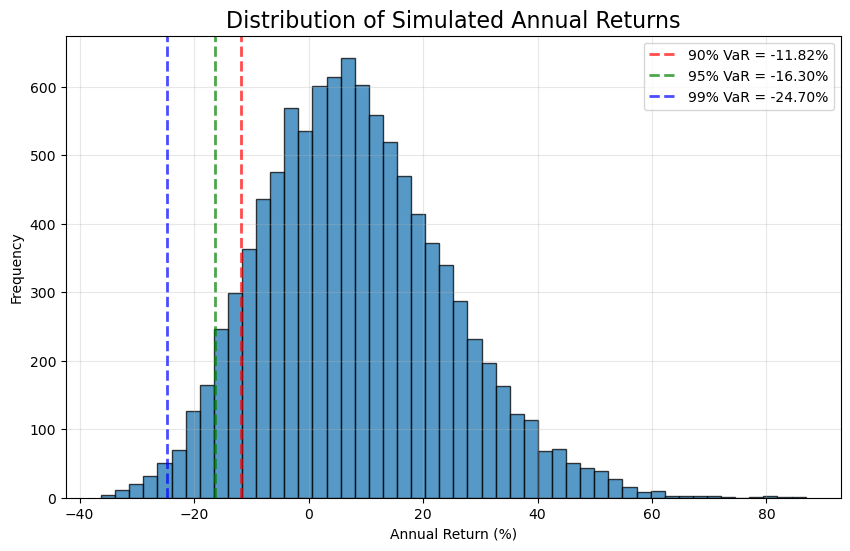

In [7]:
# Plotting distribution of expected returns

plt.figure(figsize = (10, 6))

plt.hist(
    returns,
    bins = 50,
    edgecolor = 'black',
    alpha = 0.75
)

plt.title('Distribution of Simulated Annual Returns', fontsize=16)
plt.xlabel('Annual Return (%)')
plt.ylabel('Frequency')


for confidence, var, colorchoice in zip([90, 95, 99], [var90, var95, var99], ['r', 'g', 'b']):
    plt.axvline(
        var,
        color = colorchoice,
        alpha = 0.7,
        linestyle = '--',
        linewidth = 2,
        label = f'{confidence}% VaR = {var:.2f}%'
    )

plt.legend()
plt.grid(alpha=0.3)

plt.show()

## The Monte Carlo pricing formula is:
$$
\begin{aligned}
\text C = e^{-rT}\mathbb{E}[max(S_T - K, 0)]
\end{aligned}
$$ 
$C$: Price of the option today <br>
$r$: Annual risk free interest rate <br>
$T$: Time until option expires (in years) <br> 
So, $e^{-rT}$ forms the discount rate <br>
$S_{T}$: Final stock price <br>
$K$: Strike price (Price paid for the option)

In [8]:
# Monte Carlo European Call Option Pricing

K = 110 
r = 0.05
T = 1 

payoff = S_t[-1, :] - K # Obtaining the final price and transposing it so theat each simulation can be calculated
payoff[payoff < 0] = 0 # Essentially finding the max. All options with negative returns are instead set to 0 

# This could also rather just be done with np.maximum but I was using np.max instead and it wasnt working so i did this :))))))))
# These functions do 2 different things, and using np.maximum will be faster as less memory is used
# This is because a temporary boolean array is created using the above method
# np.maximum(St-K, 0) compares each element with 0 and returns the larger value. np.max instead finds the largest element in the entire array
# payoff = np.maximum(S_t[-1] - K, 0) -> proper implementation

avg_payoff = np.mean(payoff) # This is the expected value

# Discount the expected payoff back to its present value
C_monte = np.exp(-r*T)*avg_payoff
print(f'European call option price: {C_monte: .2f}')

European call option price:  5.38
